In [1]:
%load_ext autoreload
%autoreload 2

import concurrent.futures
from cmipper import utils, config, parallelised_download_and_process, file_ops
import xarray as xa
import datetime
import numpy as np
from tqdm.auto import tqdm

/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# finding past and future matching variables and institutes

In [103]:
from pyesgf.search import SearchConnection
facets='project,product,institute,model,experiment,ensemble,variable,table,realm,cmor_table,time_frequency,grid,version'

from pyesgf.search import SearchConnection

# Use a distributed search to query all nodes
conn = SearchConnection('https://esgf-node.llnl.gov/esg-search', distrib=True)

# Set up the context for CMIP6
ctx = conn.new_context(
    project="CMIP6",
    variable="tos",  # Replace with your desired variable
    experiment_id="historical",
    # experiment=["historical", "ssp126"],  # Adjust experiments as needed
    latest=True,  # Retrieve only the latest datasets
    facets=facets,
)

try:
    print(f"Found {ctx.hit_count} files across distributed nodes")
    results = ctx.search()
    print(f"Number of datasets: {len(results)}")

    if ctx.hit_count > 0:
        ds = ctx.search()[1]
        files = ds.file_context().search()
        for f in files:
            print(f.download_url)

except IndexError:
    print("No results found")


Found 4871 files across distributed nodes
Number of datasets: 4871



-------------------------------------------------------------------------------
Warning - defaulting to search with facets=*

This behavior is kept for backward-compatibility, but ESGF indexes might not
successfully perform a distributed search when this option is used, so some
results may be missing.  For full results, it is recommended to pass a list of
facets of interest when instantiating a context object.  For example,

      ctx = conn.new_context(facets='project,experiment_id')

Only the facets that you specify will be present in the facets_counts dictionary.

This warning is displayed when a distributed search is performed while using the
facets=* default, a maximum of once per context object.  To suppress this warning,
set the environment variable ESGF_PYCLIENT_NO_FACETS_STAR_WARNING to any value
or explicitly use  conn.new_context(facets='*')

-------------------------------------------------------------------------------


http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_18500101-18991230.nc
http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_19000101-19491230.nc
http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_19500101-19991230.nc
http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_20000101-20141230.nc


In [ ]:
result = ctx.search()[1]


In [129]:
# get list of files
files = result.file_context().search(facets=facets)
for f in files:
    print(f.download_url)


-------------------------------------------------------------------------------
Warning - defaulting to search with facets=*

This behavior is kept for backward-compatibility, but ESGF indexes might not
successfully perform a distributed search when this option is used, so some
results may be missing.  For full results, it is recommended to pass a list of
facets of interest when instantiating a context object.  For example,

      ctx = conn.new_context(facets='project,experiment_id')

Only the facets that you specify will be present in the facets_counts dictionary.

This warning is displayed when a distributed search is performed while using the
facets=* default, a maximum of once per context object.  To suppress this warning,
set the environment variable ESGF_PYCLIENT_NO_FACETS_STAR_WARNING to any value
or explicitly use  conn.new_context(facets='*')

-------------------------------------------------------------------------------


http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_18500101-18991230.nc
http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_19000101-19491230.nc
http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_19500101-19991230.nc
http://esgf-data1.llnl.gov/thredds/fileServer/css03_data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Oday/tos/gn/v20191011/tos_Oday_UKESM1-0-LL_historical_r7i1p1f3_gn_20000101-20141230.nc


In [134]:
f.size

1076029003

In [118]:
ctx.search()
datasets = ctx.search()
total_files = sum(len(ds.file_context().search()) for ds in datasets)
print(f"Total number of files: {total_files}")


-------------------------------------------------------------------------------
Warning - defaulting to search with facets=*

This behavior is kept for backward-compatibility, but ESGF indexes might not
successfully perform a distributed search when this option is used, so some
results may be missing.  For full results, it is recommended to pass a list of
facets of interest when instantiating a context object.  For example,

      ctx = conn.new_context(facets='project,experiment_id')

Only the facets that you specify will be present in the facets_counts dictionary.

This warning is displayed when a distributed search is performed while using the
facets=* default, a maximum of once per context object.  To suppress this warning,
set the environment variable ESGF_PYCLIENT_NO_FACETS_STAR_WARNING to any value
or explicitly use  conn.new_context(facets='*')

-------------------------------------------------------------------------------

----------------------------------------------------

KeyboardInterrupt: 

In [113]:
result_set[100]

In [ ]:

conn = SearchConnection('https://esgf.ceda.ac.uk/esg-search', distrib=True)


ctx = conn.new_context(
    project="CMIP5",
    realm="atmos", ensemble=["r1i1p1","r2i1p1"], latest=True,
    facets=facets)# dataset_id_pattern = "cmip5.output1.MOHC.HadGEM2-CC.historical.mon.atmos.Amon.*"
# results = ctx.search(query="id:%s" % dataset_id_pattern)
# len(results)
try:
    print(f"Found {ctx.hit_count} files")
    # ds = ctx.search()[0]
    # files = ds.file_context().search()
    # for f in files:
        # print(f.download_url)
except IndexError:
    print("No results found")

Found 13102 files


In [62]:
from pyesgf.search import SearchConnection

variable_id = "tos"

# Connect to ESGF Node
# conn = SearchConnection('https://esgf-node.llnl.gov/esg-search', distrib=True)
conn = SearchConnection('https://esgf.ceda.ac.uk/esg-search', distrib=False)

# Query datasets for a specific variable and experiments
def query_datasets(variable_id, experiments):
    context = conn.new_context(
        project="CMIP6", 
        variable=variable_id, 
        experiment=experiments,
        replica=False,
        facets="project,experiment_id,variable_id,source_id,institution_id"
    )
    return context.search()

# Query historical and SSP datasets
historical_datasets = query_datasets(variable_id=variable_id, experiments="historical")
ssp_datasets = query_datasets(variable_id=variable_id, experiments="ssp126")

# Inspect results
print(f"Searching for '{variable_id}' datasets")
print(f"Found {len(historical_datasets)} historical datasets")
print(f"Found {len(ssp_datasets)} SSP datasets")

Searching for 'tos' datasets
Found 0 historical datasets
Found 0 SSP datasets


In [46]:
context = conn.new_context(project="CMIP6", facets="variable_id")
variable_facets = context.facet_counts["variable_id"]
print(variable_facets.keys())


dict_keys(['zvelsurf', 'zvelbase', 'ztp', 'zsatcalc', 'zsatarag', 'zostoga', 'zossq', 'zos', 'zoocos', 'zooc', 'zo2min', 'zmtnt', 'zmswaero', 'zmlwaero', 'zmla', 'zmicroos', 'zmicro', 'zmesoos', 'zmeso', 'zhalfo', 'zhalf', 'zg7h', 'zg500', 'zg1000', 'zg100', 'zg10', 'zg', 'zfullo', 'zfull', 'yvelsurf', 'yvelmean', 'yvelbase', 'ygwdparam', 'xvelsurf', 'xvelmean', 'xvelbase', 'xgwdparam', 'wtem', 'wtd', 'wsgmax10m', 'wo', 'wmo', 'wilt', 'wfonocorr', 'wfo', 'wfcorr', 'wetss', 'wetso4', 'wetso2', 'wetoa', 'wetnoy', 'wetnh4', 'wetnh3', 'wetlandFrac', 'wetlandCH4prod', 'wetlandCH4cons', 'wetlandCH4', 'wetdust', 'wetbc', 'wbptemp7h', 'wbptemp', 'wap7h', 'wap500', 'wap2', 'wap', 'wa', 'vwap', 'vtendogw', 'vtendnogw', 'vtem', 'vt100', 'vt', 'vsfsit', 'vsfriver', 'vsfpr', 'vsfevap', 'vsfcorr', 'vsf', 'vqint', 'vortmean', 'volo', 'volcello', 'vo', 'vmrox', 'vmo', 'vegHeightTree', 'vegHeightShrub', 'vegHeightPasture', 'vegHeightGrass', 'vegHeightCrop', 'vegHeight', 'vegFrac', 'vas', 'va7h', 'va27'

# Testing downloaded files for past-future continuity
And making the various processing functions work

In [9]:
# ScenarioMIP/AWI/AWI-CM-1-1-MR/ + CMIP – no coordinates. Fixed with cdo. THIS IS THE ONE FOR TOS, THETAO, SO, RSDO

# PROBLEM FILES
# ScenarioMIP/CSIRO/ACCESS-ESM1-5/ – dates way in future: `parent_time_units: days since 1850-1-1` – seems intentional: TOOD: subset download by date


# ScenarioMIP/NOAA-GFDL/GFDL-ESM4/ – longitudes are 0-360. What stage is this dealt with? Also, no arag.

In [8]:
xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ESM4/ssp126/r1i1p1f1/Omon/po4/gr/v20180701/extracted_lev/po4_Omon_GFDL-ESM4_ssp126_r1i1p1f1_gr_205501-207412.nc").lon

<xarray.DataArray 'lon' (lon: 360)> Size: 3kB
array([  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5])
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    long_name:      longitude
    units:          degrees_east
    axis:           X
    bounds:         lon_bnds
    standard_name:  longitude
    cell_methods:   time: point

## Processing AWI

In [6]:
from pathlib import Path
import xarray as xa
import subprocess
import glob
from tempfile import TemporaryDirectory


def create_remap_textfile(output_dir, xsize=360, ysize=180, xfirst=-179.5, xinc=1.0, yfirst=-89.5, yinc=1.0):
    """
    Create a remap grid description file for CDO.
    """
    remap_file = Path(output_dir) / "remap_grid.txt"
    with remap_file.open("w") as f:
        f.write(f"gridtype = lonlat\n")
        f.write(f"xsize = {xsize}\n")
        f.write(f"ysize = {ysize}\n")
        f.write(f"xfirst = {xfirst}\n")
        f.write(f"xinc = {xinc}\n")
        f.write(f"yfirst = {yfirst}\n")
        f.write(f"yinc = {yinc}\n")
    return remap_file


def extract_top_20_depths(nc_fp):
    """
    Extract the top 20 depths from a NetCDF file and overwrite it.
    """
    ds = xa.open_dataset(nc_fp)
    depth_dim = "depth" if "depth" in ds.dims else "lev" if "lev" in ds.dims else None
    
    if depth_dim:
        ds = ds.isel({depth_dim: slice(0, 2)})
        temp_dir = Path(nc_fp).parent / "extracted_levs"
        temp_dir.mkdir(exist_ok=True)
        temp_file = Path(temp_dir) / nc_fp.name
        if temp_file.exists():
            print(f"{temp_file} already exists. Skipping...")
        else:
            ds.to_netcdf(temp_file)
            print(f"\tProcessed file saved to temporary location: {temp_file}")
        return temp_file
    else:
        print(f"No 'depth' or 'lev' dimension found in {nc_fp} | Skipping level extraction.")
        return nc_fp


def remapycon_to_grid(input_file, remap_file, output_file):
    """
    Use CDO remapycon to remap the input NetCDF file to a regular grid.
    """
    cmd = [
        "cdo", f"remapycon,{remap_file}",
        input_file, output_file
    ]
    print(f"\tRemapping {input_file} -> {output_file}")
    try:
        subprocess.run(cmd, check=True)
        print(f"Remapped: {input_file} -> {output_file}")
    except subprocess.CalledProcessError as e:
        print(f"Error remapping {input_file}: {e}")


class NetCDFProcessingPipeline:
    def __init__(self, parent_dir):
        """
        Initialize the pipeline with the parent directory containing subdirectories of .nc files.
        """
        self.parent_dir = Path(parent_dir)

    def process_directory(self, subdirectory):
        """
        Process all .nc files in a single subdirectory.
        """
        subdirectory = Path(subdirectory)
        
        # Skip directories that already contain "remapped" in the path
        if "remapped" in subdirectory.parts:
            print(f"Skipping directory (filepath contains 'remapped'): {subdirectory}")
            return
        
        # 1. Create the remap text file
        remap_file = create_remap_textfile(subdirectory)

        # 2. Process each .nc file in the subdirectory
        nc_fps = list(subdirectory.glob("*.nc"))
        remap_dir_fp = subdirectory / "remapped"
        
        print(f"\tProcessing {len(list(nc_fps))} files in {subdirectory}")
        for nc_fp in nc_fps:
            remap_dir_fp.mkdir(exist_ok=True)
            output_file = remap_dir_fp / nc_fp.name
            if output_file.exists():
                print(f"{output_file} already exists. Skipping...")
            else:
                # Extract top 20 depths if applicable
                if "extracted_levs" not in subdirectory.parts:
                    nc_fp = extract_top_20_depths(nc_fp)

                if not output_file.exists():
                    remapycon_to_grid(nc_fp, remap_file, output_file)
                else:
                    print(f"{output_file} already exists. Skipping...")
                # Remap to a regular grid

    def run(self):
        """
        Run the pipeline on all subdirectories of the parent directory.
        """
        subdirs = [d for d in self.parent_dir.rglob('*') if d.is_dir()]
        for subdir in subdirs:
            print(f"Scanning directory: {subdir}")
            self.process_directory(subdir)

parent_dir = "/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so"
pipeline = NetCDFProcessingPipeline(parent_dir)
pipeline.run()

Scanning directory: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn
	Processing 0 files in /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn
Scanning directory: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218
	Processing 8 files in /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218
/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_187101-188012.nc already exists. Skipping...
	Remapping /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_187101-188012.nc -> /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/s

cdi  warning (cdf_set_var): Inconsistent variable definition for lat_bnds!
cdi  warning (cdf_set_var): Inconsistent variable definition for lon_bnds!


cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid
cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid, with source mask (752658)
cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid, with source mask (734901)
cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid, with source mask (718617)
cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid, with source mask (705106)
cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid, with source mask (693398)
cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid, with source mask (683281)
cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x

cdi  warning (cdfScanVarAttr): NetCDF: Variable not found - >lat<
cdi  warning (cdfScanVarAttr): NetCDF: Variable not found - >lon<

cdo    remapcon (Abort): Source grid cell center coordinates missing!


Error remapping /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_186101-187012.nc: Command '['cdo', 'remapycon,/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remap_grid.txt', PosixPath('/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_186101-187012.nc'), PosixPath('/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_186101-187012.nc')]' returned non-zero exit status 1.
/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_185101-186012.nc already exists. Skipping...
	Remapping /maps/rt582/cmi

cdi  warning (cdf_set_var): Inconsistent variable definition for lat_bnds!
cdi  warning (cdf_set_var): Inconsistent variable definition for lon_bnds!


cdo    remapcon: YAC first order conservative weights from unstructured (830305) to lonlat (360x180) grid
Remapped: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_185101-186012.nc -> /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_185101-186012.nc
/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_200101-201012.nc already exists. Skipping...
	Remapping /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_200101-201012.nc -> /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/so_Omon_

cdi  warning (cdf_set_var): Inconsistent variable definition for lat_bnds!
cdi  warning (cdf_set_var): Inconsistent variable definition for lon_bnds!


KeyboardInterrupt: 

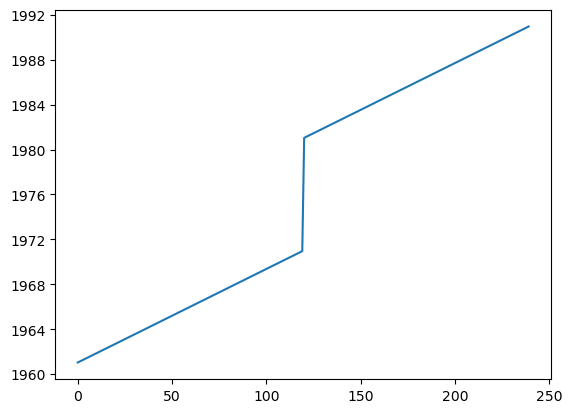

In [14]:
fps = ["/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/thetao/gn/v20181218/remapped/thetao_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_196101-197012.nc", "/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/thetao/gn/v20181218/remapped/thetao_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_198101-199012.nc"]
import matplotlib.pyplot as plt
plt.plot(xa.open_mfdataset(fps).time.values)

In [28]:
-90 + 0.25*720

90.0

In [21]:
nc_dir_fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped"
xa.open_mfdataset(nc_dir_fp.glob("*.nc"))

AttributeError: 'str' object has no attribute 'glob'

In [27]:
xa.open_dataset("/maps/rt582/cmipper/test1.nc")

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy', 'rasterio']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

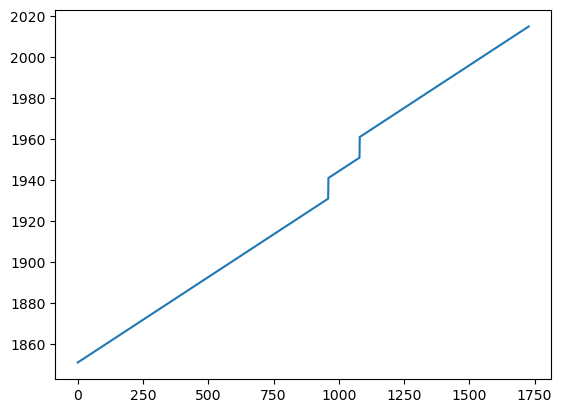

In [22]:
nc_dir_fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/tos/gn/v20181218"

# open all files in dir
plt.plot(xa.open_mfdataset(f"{nc_dir_fp}/*.nc").time.values)

In [7]:
# xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_185001-185012.nc")
xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/thetao/gn/v20181218/remapped/thetao_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_196101-197012.nc")

<xarray.Dataset> Size: 62MB
Dimensions:    (time: 120, bnds: 2, lon: 360, lat: 180, depth: 2)
Coordinates:
  * time       (time) datetime64[ns] 960B 1961-01-16T12:00:00 ... 1970-12-16T...
  * lon        (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * depth      (depth) float64 16B -0.0 10.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2kB ...
    thetao     (time, depth, lat, lon) float32 62MB ...
Attributes: (12/42)
    CDI:                    Climate Data Interface version 2.4.0 (https://mpi...
    Conventions:            CF-1.7 CMIP-6.2
    source:                 AWI-CM-1-1-MR
    institution:            Alfred Wegener Institute, Helmholtz Centre for Po...
    frequency:              mon
    activity_id:            CMIP
    ...                     ...
    parent_mip_era:         CMIP6
    parent_source_id:       AWI-CM-1-1-MR
    parent_time_units:      days since 2401-1-1
    parent_variant_label:   r1i1p1f1
    history:                Tue Nov 19 22:44:57 2024: cdo -O -s -f nc -remapc...
    CDO:                    Climate Data Operators version 2.4.0 (https://mpi...

In [8]:
xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_200101-201012.nc")

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import xarray as xa
import subprocess


def create_remap_textfile(output_dir, xsize=360, ysize=180, xfirst=-179.5, xinc=1.0, yfirst=-89.5, yinc=1.0):
    """
    Create a remap grid description file for CDO.
    """
    remap_file = Path(output_dir) / "remap_grid.txt"
    with remap_file.open("w") as f:
        f.write(f"gridtype = lonlat\n")
        f.write(f"xsize = {xsize}\n")
        f.write(f"ysize = {ysize}\n")
        f.write(f"xfirst = {xfirst}\n")
        f.write(f"xinc = {xinc}\n")
        f.write(f"yfirst = {yfirst}\n")
        f.write(f"yinc = {yinc}\n")
    return remap_file


def process_nc_file(nc_fp, remap_file, output_dir):
    """
    Process a single NetCDF file: extract top 20 levels and remap.
    """
    try:
        # Load dataset and extract top 20 depths
        ds = xa.open_dataset(nc_fp)
        depth_dim = "depth" if "depth" in ds.dims else "lev" if "lev" in ds.dims else None
        if depth_dim:
            ds = ds.isel({depth_dim: slice(0, 20)})
        else:
            print(f"No 'depth' or 'lev' dimension found in {nc_fp}. Skipping...")
            return
        
        # Output remapped file
        output_file = output_dir / nc_fp.name
        if output_file.exists():
            print(f"{output_file} already exists. Skipping...")
        else:
            ds = utils.process_xa_d(ds)
            ds = utils.cdo_remap(ds, remap_file, remap_method="remapcon")
            print(f"Saving remapped file: {output_file}")
            ds.to_netcdf(output_file)
    except Exception as e:
        print(f"Failed to process {nc_fp}: {e}")


class NetCDFProcessingPipeline:
    def __init__(self, parent_dir):
        """
        Initialize the pipeline with the parent directory containing subdirectories of .nc files.
        """
        self.parent_dir = Path(parent_dir)

    def process_directory(self, subdirectory):
        """
        Process all .nc files in a single subdirectory.
        """
        subdirectory = Path(subdirectory)
        
        # Skip directories that already contain "remapped" in the path
        if "remapped" in subdirectory.parts:
            print(f"Skipping directory (contains 'remapped'): {subdirectory}")
            return
        
        # Create remap text file
        remap_file = create_remap_textfile(subdirectory)

        # Prepare remap output directory
        remap_dir_fp = subdirectory / "remapped"
        remap_dir_fp.mkdir(exist_ok=True)

        # Process each NetCDF file in the directory
        nc_fps = list(subdirectory.glob("*.nc"))
        print(f"\tProcessing {len(nc_fps)} files in {subdirectory}")
        for nc_fp in nc_fps:
            process_nc_file(nc_fp, remap_file, remap_dir_fp)

    def run(self):
        """
        Run the pipeline on all subdirectories of the parent directory.
        """
        subdirs = [d for d in self.parent_dir.rglob('*') if d.is_dir()]
        for subdir in subdirs:
            print(f"Scanning directory: {subdir}")
            self.process_directory(subdir)


# Run the pipeline
parent_dir = "/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so"
pipeline = NetCDFProcessingPipeline(parent_dir)
pipeline.run()


Scanning directory: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn
	Processing 0 files in /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn
Scanning directory: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/remapped
Skipping directory (contains 'remapped'): /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/remapped
Scanning directory: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218
	Processing 8 files in /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218
/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_187101-188012.nc already exists. Skipping...
/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AW

In [9]:
xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_186101-187012.nc")

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*

In [ ]:
from pathlib import Path
import xarray as xa
import subprocess
from tempfile import TemporaryDirectory
from concurrent.futures import ProcessPoolExecutor, as_completed


def create_remap_textfile(output_dir, xsize=360, ysize=180, xfirst=-179.5, xinc=1.0, yfirst=-89.5, yinc=1.0):
    """
    Create a remap grid description file for CDO.
    """
    remap_file = Path(output_dir) / "remap_grid.txt"
    with remap_file.open("w") as f:
        f.write(f"gridtype = lonlat\n")
        f.write(f"xsize = {xsize}\n")
        f.write(f"ysize = {ysize}\n")
        f.write(f"xfirst = {xfirst}\n")
        f.write(f"xinc = {xinc}\n")
        f.write(f"yfirst = {yfirst}\n")
        f.write(f"yinc = {yinc}\n")
    return remap_file


def extract_top_20_depths(nc_fp, temp_dir):
    """
    Extract the top 20 depths from a NetCDF file and return the path to the processed file.
    """
    ds = xa.open_dataset(nc_fp)
    depth_dim = "depth" if "depth" in ds.dims else "lev" if "lev" in ds.dims else None
    
    if depth_dim:
        # Extract top 20 levels
        ds = ds.isel({depth_dim: slice(0, 20)})
        temp_file = Path(temp_dir) / nc_fp.name
        ds.to_netcdf(temp_file)
        print(f"\tExtracted top 20 levels to: {temp_file}")
        return temp_file
    else:
        print(f"No 'depth' or 'lev' dimension found in {nc_fp} | Skipping level extraction.")
        return nc_fp


def remapycon_to_grid(input_file, remap_file, output_file):
    """
    Use CDO remapycon to remap the input NetCDF file to a regular grid.
    """
    cmd = [
        "cdo", f"remapycon,{remap_file}",
        str(input_file), str(output_file)
    ]
    try:
        subprocess.run(cmd, check=True)
        print(f"Remapped: {input_file} -> {output_file}")
    except subprocess.CalledProcessError as e:
        print(f"Error remapping {input_file}: {e}")


def process_file(nc_fp, remap_file, remap_dir_fp, temp_dir):
    """
    Extract top 20 depths and remap the NetCDF file.
    """
    output_file = remap_dir_fp / nc_fp.name
    if output_file.exists():
        print(f"{output_file} already exists. Skipping...")
        return

    # Extract top 20 depths
    processed_file = extract_top_20_depths(nc_fp, temp_dir)

    # Remap to a regular grid
    remapycon_to_grid(processed_file, remap_file, output_file)


class NetCDFProcessingPipeline:
    def __init__(self, parent_dir):
        """
        Initialize the pipeline with the parent directory containing subdirectories of .nc files.
        """
        self.parent_dir = Path(parent_dir)

    def process_directory(self, subdirectory, max_workers=4):
        """
        Process all .nc files in a single subdirectory using parallel processing.
        """
        subdirectory = Path(subdirectory)

        # Skip directories that already contain "remapped" in the path
        if "remapped" in subdirectory.parts:
            print(f"Skipping directory (contains 'remapped'): {subdirectory}")
            return
        
        # Create the remap text file
        remap_file = create_remap_textfile(subdirectory)
        remap_dir_fp = subdirectory / "remapped"
        remap_dir_fp.mkdir(exist_ok=True)

        # Collect all .nc files in the subdirectory
        nc_fps = list(subdirectory.glob("*.nc"))
        
        if len(nc_fps) == 0:
            print(f"No .nc files found in {subdirectory}")
            return

        with TemporaryDirectory() as temp_dir, ProcessPoolExecutor(max_workers=max_workers) as executor:
            futures = {
                executor.submit(process_file, nc_fp, remap_file, remap_dir_fp, temp_dir): nc_fp
                for nc_fp in nc_fps
            }
            for future in as_completed(futures):
                try:
                    future.result()
                except Exception as e:
                    print(f"Error processing file {futures[future]}: {e}")

    def run(self, max_workers=4):
        """
        Run the pipeline on all subdirectories of the parent directory using parallel processing.
        """
        subdirs = [d for d in self.parent_dir.rglob('*') if d.is_dir()]
        for subdir in subdirs:
            print(f"Scanning directory: {subdir}")
            self.process_directory(subdir, max_workers=max_workers)


# Initialize and run the pipeline
parent_dir = "/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so"
pipeline = NetCDFProcessingPipeline(parent_dir)
pipeline.run(max_workers=8)  # Adjust max_workers based on your available CPU cores


Scanning directory: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn
	Processing 0 files in /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn
Scanning directory: /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218
	Processing 8 files in /maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218
/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_187101-188012.nc already exists. Skipping...
/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/remapped/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_193101-194012.nc already exists. Skipping...


In [3]:
xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_187101-188012.nc")

FileNotFoundError: [Errno 2] No such file or directory: '/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/so/gn/v20181218/extracted_levs/so_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_187101-188012.nc'

In [ ]:
# for a directory of .nc files, create remap textfile
# for directories with 'depth' as a dimension, extract top 20 depths and overwrite file
# for directories, remapycon to grid

In [38]:
# testing different files
fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/ScenarioMIP/AWI/AWI-CM-1-1-MR/ssp126/r1i1p1f1/Omon/so/gn/v20181218/so_Omon_AWI-CM-1-1-MR_ssp126_r1i1p1f1_gn_201501-202012.nc"
test = xa.open_dataset(fp)
test.isel(depth=slice(0,1)).to_netcdf("/maps/rt582/cmipper/shallow_so.nc")
test

<xarray.Dataset> Size: 11GB
Dimensions:    (time: 72, bnds: 2, depth: 46, ncells: 830305, vertices: 16)
Coordinates:
  * time       (time) datetime64[ns] 576B 2015-01-16T12:00:00 ... 2020-12-16T...
  * depth      (depth) float64 368B -0.0 10.0 20.0 ... 5.4e+03 5.65e+03 5.9e+03
    lat        (ncells) float64 7MB ...
    lon        (ncells) float64 7MB ...
Dimensions without coordinates: bnds, ncells, vertices
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 1kB ...
    so         (time, depth, ncells) float32 11GB ...
    lat_bnds   (ncells, vertices) float64 106MB ...
    lon_bnds   (ncells, vertices) float64 106MB ...
Attributes: (12/39)
    frequency:              mon
    activity_id:            ScenarioMIP
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2018-12-18T12:00:00Z
    data_specs_version:     01.00.27
    experiment:             ssp126
    ...                     ...
    parent_activity_id:     CMIP
    parent_experiment_id:   historical
    parent_mip_era:         CMIP6
    parent_source_id:       AWI-CM-1-1-MR
    parent_time_units:      days since 1850-1-1
    parent_variant_label:   r1i1p1f1

In [40]:
xa.open_dataset("/maps/rt582/cmipper/test_so2.nc")

<xarray.Dataset> Size: 299MB
Dimensions:    (time: 72, bnds: 2, lon: 1440, lat: 720, depth: 1)
Coordinates:
  * time       (time) datetime64[ns] 576B 2015-01-16T12:00:00 ... 2020-12-16T...
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * lat        (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.25 89.5 89.75
  * depth      (depth) float64 8B -0.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 1kB ...
    so         (time, depth, lat, lon) float32 299MB ...
Attributes: (12/42)
    CDI:                    Climate Data Interface version 2.4.0 (https://mpi...
    Conventions:            CF-1.7 CMIP-6.2
    source:                 AWI-CM-1-1-MR
    institution:            Alfred Wegener Institute, Helmholtz Centre for Po...
    frequency:              mon
    activity_id:            ScenarioMIP
    ...                     ...
    parent_mip_era:         CMIP6
    parent_source_id:       AWI-CM-1-1-MR
    parent_time_units:      days since 1850-1-1
    parent_variant_label:   r1i1p1f1
    history:                Tue Nov 19 13:50:09 2024: cdo remapycon,regular_g...
    CDO:                    Climate Data Operators version 2.4.0 (https://mpi...

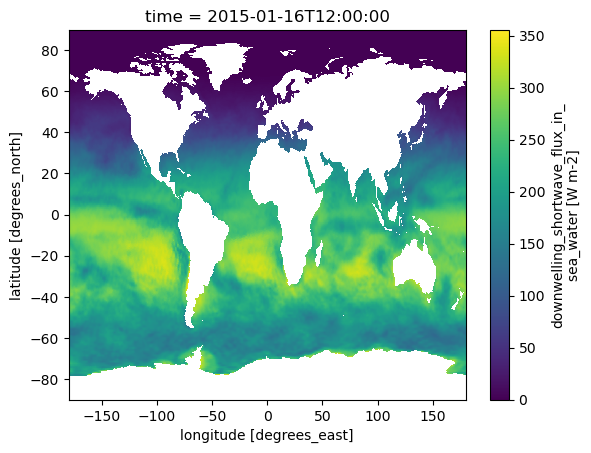

In [35]:
# xa.open_dataset("/maps/rt582/cmipper/test2.nc").rsdo.isel(time=0).plot()  # this works
xa.open_dataset("/maps/rt582/cmipper/test4.nc").rsdo.isel(time=0).plot()

In [29]:
# testing different files
fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/ScenarioMIP/AWI/AWI-CM-1-1-MR/ssp126/r1i1p1f1/Omon/so/gn/v20181218/so_Omon_AWI-CM-1-1-MR_ssp126_r1i1p1f1_gn_201501-202012.nc"
test = xa.open_dataset(fp)
# test.isel(depth=slice(0,3)).to_netcdf("/maps/rt582/cmipper/shallow_so.nc")
test

<xarray.Dataset> Size: 11GB
Dimensions:    (time: 72, bnds: 2, depth: 46, ncells: 830305, vertices: 16)
Coordinates:
  * time       (time) datetime64[ns] 576B 2015-01-16T12:00:00 ... 2020-12-16T...
  * depth      (depth) float64 368B -0.0 10.0 20.0 ... 5.4e+03 5.65e+03 5.9e+03
    lat        (ncells) float64 7MB ...
    lon        (ncells) float64 7MB ...
Dimensions without coordinates: bnds, ncells, vertices
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 1kB ...
    so         (time, depth, ncells) float32 11GB ...
    lat_bnds   (ncells, vertices) float64 106MB ...
    lon_bnds   (ncells, vertices) float64 106MB ...
Attributes: (12/39)
    frequency:              mon
    activity_id:            ScenarioMIP
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2018-12-18T12:00:00Z
    data_specs_version:     01.00.27
    experiment:             ssp126
    ...                     ...
    parent_activity_id:     CMIP
    parent_experiment_id:   historical
    parent_mip_era:         CMIP6
    parent_source_id:       AWI-CM-1-1-MR
    parent_time_units:      days since 1850-1-1
    parent_variant_label:   r1i1p1f1

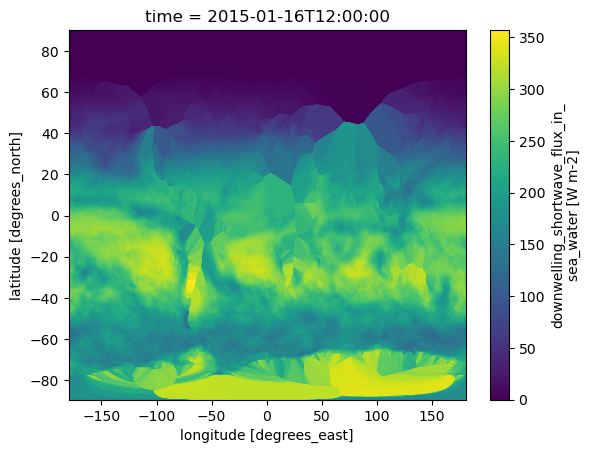

In [27]:
xa.open_dataset("/maps/rt582/cmipper/test.nc")["rsdo"].isel(time=0).plot()

In [23]:
test_so = xa.open_dataset("/maps/rt582/cmipper/test_so.nc")

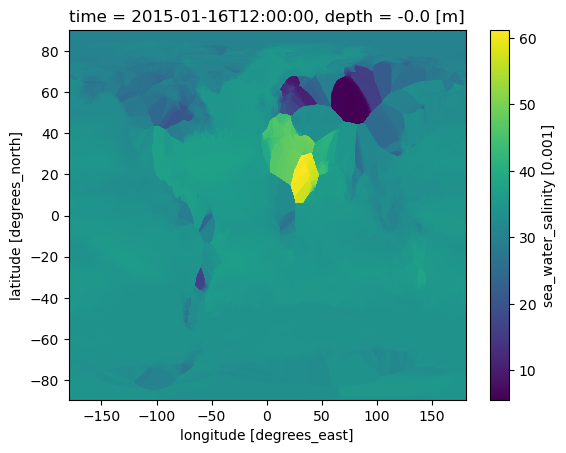

In [25]:
test_so["so"].isel(time=0, depth=0).plot()

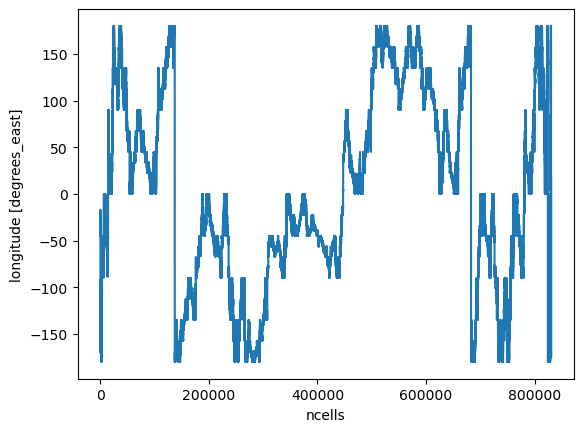

In [7]:
test.lon.plot()

In [12]:
len(ds['lat'].values)

830305

In [9]:
ds = test

# Step 1: Extract lat/lon as unique values and determine the grid shape
unique_lats = np.unique(ds['lat'].values)
unique_lons = np.unique(ds['lon'].values)

# Determine grid shape
lat_grid, lon_grid = np.meshgrid(unique_lats, unique_lons, indexing="ij")

# Step 2: Create a lookup to map `ncells` indices to the lat/lon grid
# Assuming `rsdo` is the variable of interest
n_cells = len(ds['lat'])

# Reshape `rsdo` to match the new (time, lat, lon) grid
reshaped_rsdo = np.full((len(ds['time']), len(unique_lats), len(unique_lons)), np.nan)

# Map ncells into 2D grid space
for i in range(n_cells):
    lat_idx = np.where(unique_lats == ds['lat'][i].values)[0][0]
    lon_idx = np.where(unique_lons == ds['lon'][i].values)[0][0]
    reshaped_rsdo[:, lat_idx, lon_idx] = ds['rsdo'][:, i]

# Step 3: Create a new Dataset with the reordered dimensions
ds_new = xa.Dataset(
    {
        "rsdo": (["time", "lat", "lon"], reshaped_rsdo),
    },
    coords={
        "time": ds['time'],
        "lat": unique_lats,
        "lon": unique_lons,
    },
)

print(ds_new)

MemoryError: Unable to allocate 5.02 TiB for an array with shape (830305, 830305) and data type float64

In [ ]:
fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r3i1p1f1/Omon/no3/gn/v20191203/no3_Omon_ACCESS-ESM1-5_historical_r3i1p1f1_gn_199001-199912.nc"
no3 = xa.open_dataset(fp)
no3

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 120, bnds: 2, lev: 50, j: 300, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 960B 1990-01-16T12:00:00 ... 19...
  * lev                 (lev) float64 400B 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB ...
    longitude           (j, i) float64 864kB ...
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 2kB ...
    lev_bnds            (lev, bnds) float64 800B ...
    vertices_latitude   (j, i, vertices) float64 3MB ...
    vertices_longitude  (j, i, vertices) float64 3MB ...
    no3                 (time, lev, j, i) float32 3GB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36524.0
    creation_date:          2019-12-03T11:57:22Z
    ...                     ...
    variable_id:            no3
    variant_label:          r3i1p1f1
    version:                v20191203
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/82cd3e8c-dc15-4e95-aadf-21d2201ae2b5
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [26]:
from cmipper import processing

ds = processing.load_dataset_with_dask(
                    fp, chunk_schema=None
                )
# print(ds.no3.values.shape)
# ds.no3.isel(time=0, lev=0).plot(figsize=(4,3))

In [21]:
variable_id = "no3"
seafloor_indices = processing.gen_seafloor_indices(
                ds, var=variable_id
            )



determining seafloor indices... 


In [ ]:



ds = processing.load_dataset_with_dask(
                    fp, chunk_schema=None
                )

processing.extract_seafloor_vals_from_ds(ds, variable_id, seafloor_indices)

<xarray.Dataset> Size: 60MB
Dimensions:             (time: 120, bnds: 2, j: 300, i: 360, vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 960B 1990-01-16T12:00:00 ... 19...
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB ...
    longitude           (j, i) float64 864kB ...
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 2kB ...
    vertices_latitude   (j, i, vertices) float64 3MB ...
    vertices_longitude  (j, i, vertices) float64 3MB ...
    no3                 (time, j, i) float32 52MB nan nan nan ... nan nan nan
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36524.0
    creation_date:          2019-12-03T11:57:22Z
    ...                     ...
    variable_id:            no3
    variant_label:          r3i1p1f1
    version:                v20191203
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/82cd3e8c-dc15-4e95-aadf-21d2201ae2b5
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [20]:
# xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon/rsdo/gn/v20181218/rsdo_Omon_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_185101-186012.nc")
xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-ESM-1-1-LR/historical/r1i1p1f1/Omon/rsdo/gn/v20200212/rsdo_Omon_AWI-ESM-1-1-LR_historical_r1i1p1f1_gn_185001-185012.nc")

<xarray.Dataset> Size: 45MB
Dimensions:    (time: 12, ncells: 126859, number_of_time_bounds: 2, vertices: 18)
Coordinates:
  * time       (time) datetime64[ns] 96B 1850-01-16T12:00:00 ... 1850-12-16T1...
    lat        (ncells) float64 1MB ...
    lon        (ncells) float64 1MB ...
Dimensions without coordinates: ncells, number_of_time_bounds, vertices
Data variables:
    rsdo       (time, ncells) float32 6MB ...
    time_bnds  (time, number_of_time_bounds) datetime64[ns] 192B ...
    lat_bnds   (ncells, vertices) float64 18MB ...
    lon_bnds   (ncells, vertices) float64 18MB ...
Attributes: (12/39)
    activity_id:            CMIP
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2020-02-12T12:00:00Z
    data_specs_version:     01.00.30
    experiment:             historical
    experiment_id:          historical
    ...                     ...
    parent_activity_id:     CMIP
    parent_experiment_id:   piControl
    parent_mip_era:         CMIP6
    parent_source_id:       AWI-ESM-1-1-LR
    parent_time_units:      days since 1692-1-1
    parent_variant_label:   r1i1p1f1

In [19]:
%load_ext autoreload
%autoreload 2

import concurrent.futures
from cmipper import utils, config, parallelised_download_and_process, file_ops
import xarray as xa
import datetime
import numpy as np
from tqdm.auto import tqdm
from coralshift.plotting import spatial_plots

import dask.array as da
from dask import delayed, compute

from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'spatial_plots' from 'coralshift.plotting' (unknown location)

# Extracting seafloor (duplicate run_main)

In [ ]:
fps = Path("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/vo/gn/v20191216").glob("*.nc")
combined = xa.open_mfdataset(fps, chunks={"lev": -1, "i": -1, "j": -1})["vo"]   # levels as single chunk since will need to index along this dimension
combined["time"] = [datetime.datetime(vv.year,vv.month,vv.day) for vv in combined["time"].values]   # from 360 calendar to datetime
combined

<xarray.DataArray 'vo' (time: 1980, lev: 75, j: 1205, i: 1440)> Size: 1TB
dask.array<concatenate, shape=(1980, 75, 1205, 1440), dtype=float32, chunksize=(1, 75, 1205, 1440), chunktype=numpy.ndarray>
Coordinates:
  * lev        (lev) float64 600B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * j          (j) int32 5kB 0 1 2 3 4 5 6 ... 1199 1200 1201 1202 1203 1204
  * i          (i) int32 6kB 0 1 2 3 4 5 6 ... 1434 1435 1436 1437 1438 1439
    latitude   (j, i) float32 7MB dask.array<chunksize=(1205, 1440), meta=np.ndarray>
    longitude  (j, i) float32 7MB dask.array<chunksize=(1205, 1440), meta=np.ndarray>
  * time       (time) datetime64[ns] 16kB 1850-01-16 1850-02-16 ... 2014-12-16
Attributes:
    standard_name:  sea_water_y_velocity
    long_name:      Sea Water Y Velocity
    comment:        mo: This variable is reported using a z* coordinate syste...
    units:          m s-1
    original_name:  mo: mask_copy((variable_name: vo), (variable_name: mask_3...
    cell_methods:   time: mean

In [ ]:
def gen_seafloor_indices(xa_da: xa.DataArray, dim: str = "lev"):
    """Generate indices of seafloor values for a given variable in an xarray dataset.

    Args:
        xa_d (xa.Dataset): xarray dataset containing variable of interest
        var (str): name of variable of interest
        dim (str, optional): dimension along which to search for seafloor values. Defaults to "lev".

    Returns:
        indices_array (np.ndarray): array of indices of seafloor values for given variable
    """
    print("\ndetermining seafloor indices... ", flush=True)
    nans = np.isnan(xa_da).sum(dim=dim)  # separate out
    indices_array = -(nans.values) - 1
    indices_array[indices_array == -(len(xa_da[dim].values) + 1)] = -1
    return indices_array


def seafloor_inds(da):
    seafloor_indices = gen_seafloor_indices(da.isel(time=0))
    proj_seafloor_indices = np.broadcast_to(
                seafloor_indices,
                (
                    len(da.time),
                    len(da.j),
                    len(da.i),
                ),  # these variable names may differ by model
            )
    return proj_seafloor_indices

seafloor_indices = seafloor_inds(combined.isel(time=slice(0,4)))


determining seafloor indices... 


In [ ]:
combined.isel(time=slice(0,4)).chunks[:3]

In [ ]:
lev_indices_da = da.from_array(seafloor_indices)
lev_indices_da

dask.array<array, shape=(4, 1205, 1440), dtype=int64, chunksize=(4, 1205, 1440), chunktype=numpy.ndarray>

In [ ]:
from tqdm.auto import tqdm
# Extract the lev dimension size
lev_dim_size = len(combined.lev)

# Create a function to perform the extraction
def extract_lev_indexed(data, lev_indices, lev_dim_size):
    # Create an array of the same shape as lev_indices with an extra dimension for lev
    expanded_lev_indices = da.zeros((lev_dim_size, *lev_indices.shape), dtype=int)
    for lev in tqdm(range(lev_dim_size)):
        expanded_lev_indices[lev, ...] = (lev_indices == lev).astype(int)

    # Convert expanded_lev_indices to a DataArray
    expanded_lev_indices = xa.DataArray(expanded_lev_indices, dims=['lev', 'time', 'j', 'i'])

    # Perform the selection using where
    extracted_data = data.where(expanded_lev_indices, drop=True).sum('lev')
    
    return extracted_data

indexed_data = extract_lev_indexed(combined.isel(time=slice(0,4)), lev_indices_da, lev_dim_size)


100%|██████████| 75/75 [00:03<00:00, 18.79it/s]


KeyboardInterrupt: 

In [ ]:

def extract_lev(data, lev_indices):
    """
    Extract the data at specified lev indices.

    Parameters:
    - data: xarray DataArray of the NetCDF data.
    - lev_indices: Dask array with the lev indices.

    Returns:
    - Indexed data as a Dask array.
    """
    # Create a meshgrid of indices for time, i, and j
    time_idx, i_idx, j_idx = da.meshgrid(
        np.arange(data.shape[0]), 
        np.arange(data.shape[2]), 
        np.arange(data.shape[3]), 
        indexing='ij'
    )
    
    # Use advanced indexing to extract the desired values
    indexed_data = data[
        time_idx, 
        lev_indices_da, 
        i_idx, 
        j_idx
    ]
    
    return indexed_data

# Apply the function to extract the indexed data
indexed_data = extract_lev(combined, lev_indices_da)

# Convert the result to an xarray DataArray
result = xa.DataArray(indexed_data, dims=('time', 'i', 'j'))

In [ ]:
import xarray as xr
import numpy as np
import dask.array as da

# Load the NetCDF file
file_path = 'path_to_your_large_file.nc'
ds = xr.open_dataset(file_path, chunks={'time': 1})

# Assuming var is the variable you're interested in
var = 'your_variable_name'
data_var = ds[var]

# Example lev_indices numpy array of shape (time, i, j)
# Replace this with your actual lev_indices array
lev_indices = np.random.randint(0, len(ds.lev), size=(len(ds.time), len(ds.i), len(ds.j)))

# Convert lev_indices to a Dask array for efficient handling
lev_indices_da = da.from_array(lev_indices, chunks=data_var.chunks[:3])

# Create a new Dask array to hold the indexed data
def extract_lev(data, lev_indices):
    """
    Extract the data at specified lev indices.

    Parameters:
    - data: xarray DataArray of the NetCDF data.
    - lev_indices: Dask array with the lev indices.

    Returns:
    - Indexed data as a Dask array.
    """
    # Create a meshgrid of indices for time, i, and j
    time_idx, i_idx, j_idx = da.meshgrid(
        np.arange(data.shape[0]), 
        np.arange(data.shape[2]), 
        np.arange(data.shape[3]), 
        indexing='ij'
    )
    
    # Use advanced indexing to extract the desired values
    indexed_data = data[
        time_idx, 
        lev_indices_da, 
        i_idx, 
        j_idx
    ]
    
    return indexed_data

# Apply the function to extract the indexed data
indexed_data = extract_lev(data_var, lev_indices_da)

# Convert the result to an xarray DataArray
result = xr.DataArray(indexed_data, dims=('time', 'i', 'j'))

# Trigger the computation (optional, depends on your use case)
result.load()  # or result.compute() if you want to compute immediately

# Save the result to a new NetCDF file (optional)
result.to_netcdf('path_to_save_indexed_data.nc')


In [ ]:
def seafloor(ds, var):
    seafloor_indices = utils.gen_seafloor_indices(ds.isel(time=0), var)
    proj_seafloor_indices = np.broadcast_to(
                seafloor_indices,
                (
                    len(ds.time),
                    len(ds.j),
                    len(ds.i),
                ),  # these variable names may differ by model
            )
    return extract_seafloor_indices(ds, proj_seafloor_indices, var)


def extract_seafloor_indices(ds, seafloor_indices, variable_id):
    new_ds = ds.copy()
    
    # Ensure seafloor_indices is computed before using it
    seafloor_indices = compute(seafloor_indices)[0]
    
    # Parallelize the extraction
    cmip6_array = delayed(utils.extract_3d_index_vals)(new_ds[variable_id], seafloor_indices)
    
    # Convert the delayed array to a Dask array
    cmip6_array = da.from_delayed(cmip6_array, shape=(len(ds.time), len(ds.j), len(ds.i)), dtype=new_ds[variable_id].dtype)
    
    new_ds[variable_id] = (["time", "j", "i"], cmip6_array)
    
    return new_ds

In [ ]:
def fp_extract(fp):
    ds = xa.open_dataset(fp, chunks={"lev": -1, "i": -1, "j": -1})
    return seafloor(ds, "vo")

In [ ]:
from dask.distributed import Client
# client = Client(n_workers=4, threads_per_worker=8, memory_limit='8GB')
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42399/status,
Dashboard: http://127.0.0.1:42399/status,Workers: 16
Total threads: 256,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44597,Workers: 16
Dashboard: http://127.0.0.1:42399/status,Total threads: 256
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:40631,Total threads: 16
Dashboard: http://127.0.0.1:45471/status,Memory: 62.98 GiB
Nanny: tcp://127.0.0.1:33805,


In [ ]:
extract_parallel = delayed(fp_extract)
fps = [f for f in Path("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/vo/gn/v20191216").iterdir() if f.is_file()]
tasks = [fp_extract(fp) for fp in list(fps)[:6]]


determining seafloor indices... 

determining seafloor indices... 

determining seafloor indices... 

determining seafloor indices... 

determining seafloor indices... 

determining seafloor indices... 


In [ ]:
results = da.compute(*tasks)

2024-06-19 12:00:46,187 - distributed.protocol.core - CRITICAL - Failed to Serialize
Traceback (most recent call last):
  File "/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/distributed/protocol/core.py", line 109, in dumps
    frames[0] = msgpack.dumps(msg, default=_encode_default, use_bin_type=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/msgpack/__init__.py", line 36, in packb
    return Packer(**kwargs).pack(o)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "msgpack/_packer.pyx", line 294, in msgpack._cmsgpack.Packer.pack
  File "msgpack/_packer.pyx", line 300, in msgpack._cmsgpack.Packer.pack
  File "msgpack/_packer.pyx", line 297, in msgpack._cmsgpack.Packer.pack
  File "msgpack/_packer.pyx", line 264, in msgpack._cmsgpack.Packer._pack
  File "msgpack/_packer.pyx", line 231, in msgpack._cmsgpack.Packer._pack
  File "msgpack/_packer.pyx", line 264, in msgp

CancelledError: ('open_dataset-time_bnds-9dbee626718b83d7405f91f5f0227921', 119, 0)

In [ ]:
%timeit computed_result = result.compute()  # 6.18 s ± 2.73 s per loop for t=4, -1 lev chunking
# 1min 12s ± 18.7 s per loop for t=16!

In [ ]:
combined["vo"]

In [ ]:
out = xa.open_dataset("https://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/rsdo/gn/v20191216/rsdo_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc")
out

In [ ]:
xa.open_dataset(
    "https://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/rsdo/gn/v20191216/rsdo_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc",
    chunks={"time": 5, "i": 90, "j": 90}
    ).isel(lev=slice(0,20)).load()

In [ ]:
from tqdm.auto import tqdm
arrs = [
    # [48, 180, 180], # 2939s (49m)
    # [5, 180, 180],  # 1677s (28m)
    # [10, 180, 180], # 1824s (30m)
    # [5, 360, 360],  # 1465s (24m)
    # [1, 180, 180],  # 1921s (32m)
    [10, 360, 360], # 4745 (1h 19m)
    [10, 480, 480], 
    # [10, 180, 180],
    # [5, 360, 360], 
    # [1, 180, 180], 
]

times = np.zeros(len(arrs))
import time
for arr_i, arr in tqdm(enumerate(arrs)):
    try:
        start = time.time()
        out = xa.open_dataset(
            "https://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/rsdo/gn/v20191216/rsdo_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc#log",
            chunks={"time": arr[0], "i": arr[1], "j": arr[2]}
            ).isel(lev=slice(0,20)).load()
        dur = time.time() - start
        times[arr_i] = dur
    except RuntimeError:
        print("failed:", arr)
     
        

In [ ]:
from tqdm.auto import tqdm
arrs = [
    # [48, 180, 180], # 2939s (49m)
    # [5, 180, 180],  # 1677s (28m)
    # [10, 180, 180], # 1824s (30m)
    # [5, 360, 360],  # 1465s (24m)
    # [1, 180, 180],  # 1921s (32m)
    # [10, 360, 360], # 4745 (1h 19m)
    [20, 3], # more than an hour
    # [10, 180, 180],
    # [5, 360, 360], 
    # [1, 180, 180], 
]

times = np.zeros(len(arrs))
import time
for arr_i, arr in tqdm(enumerate(arrs)):
    try:
        start = time.time()
        out = xa.open_dataset(
            "https://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/rsdo/gn/v20191216/rsdo_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc#log",
            chunks={"lev": arr[0], "time": arr[1]}
            ).isel(lev=slice(0,20)).load()
        dur = time.time() - start
        times[arr_i] = dur
    except RuntimeError:
        print("failed:", arr)
     
        

In [ ]:
xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/og_grid/vo/vo_uncropped_sfl-20_tp_201001-201412.nc").isel(lev=0,time=0)["vo"].plot()

In [ ]:
xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/regridded/uo/uo_uncropped_sfl-20_ll_198801-198912.nc")

In [ ]:
1465/60

In [ ]:
np.diff(times)

In [ ]:
fps = Path("/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/regridded/uo/").glob("*.nc")
ds = xa.open_mfdataset(fps)

In [ ]:
ds

In [ ]:
ds.isel(time=0).uo.plot()

In [ ]:
ds = xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/regridded/wfo/wfo_uncropped_sfc_ll_195001-196912.nc")
ds.isel(time=0)["wfo"].plot()

In [ ]:
import numpy as np
np.nanmax(ds.isel(time=0)["wfo"].values)

In [ ]:
regridded = utils.cdo_remap(ds, "/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/HadGEM3-GC31-MM_remap_template.txt")
regridded

In [ ]:
regridded.isel(time=0)["hfds"].plot()

In [ ]:
#!/usr/bin/env python
from __future__ import print_function
import requests
import xml.etree.ElementTree as ET
import numpy

# Author: Unknown
# I got the original version from a word document published by ESGF
# https://docs.google.com/document/d/1pxz1Kd3JHfFp8vR2JCVBfApbsHmbUQQstifhGNdc6U0/edit?usp=sharing

# API AT: https://github.com/ESGF/esgf.github.io/wiki/ESGF_Search_REST_API#results-pagination

def esgf_search(server="https://esgf-node.llnl.gov/esg-search/search",
                files_type="OPENDAP", local_node=True, project="CMIP6",
                verbose=False, format="application%2Fsolr%2Bjson",
                use_csrf=False, **search):
    client = requests.session()
    payload = search
    payload["project"] = project
    payload["type"]= "File"
    if local_node:
        payload["distrib"] = "false"
    if use_csrf:
        client.get(server)
        if 'csrftoken' in client.cookies:
            # Django 1.6 and up
            csrftoken = client.cookies['csrftoken']
        else:
            # older versions
            csrftoken = client.cookies['csrf']
        payload["csrfmiddlewaretoken"] = csrftoken

    payload["format"] = format

    offset = 0
    numFound = 10000
    all_files = []
    files_type = files_type.upper()
    while offset < numFound:
        payload["offset"] = offset
        url_keys = [] 
        for k in payload:
            url_keys += ["{}={}".format(k, payload[k])]

        url = "{}/?{}".format(server, "&".join(url_keys))
        # print(url)
        r = client.get(url)
        r.raise_for_status()
        resp = r.json()["response"]
        numFound = int(resp["numFound"])
        resp = resp["docs"]
        offset += len(resp)
        for d in resp:
            if verbose:
                for k in d:
                    print("{}: {}".format(k,d[k]))
            url = d["url"]
            for f in d["url"]:
                sp = f.split("|")
                if sp[-1] == files_type:
                    all_files.append(sp[0].split(".html")[0])
    return sorted(all_files)

In [ ]:
esgf_search(activity_id='CMIP', table_id='Omon', experiment_id='historical',
                  institution_id="AWI", source_id="AWI-CM-1-1-MR")

In [ ]:
parallelised_download_and_process.main(source_id="MPI-ESM1-2-HR", variable_id="po4")

In [ ]:
parallelised_download_and_process.generate_bash_commands()

In [ ]:
file_ops.read_yaml(config.model_info).keys()

In [ ]:
parallelised_download_and_process.main(source_id="MPI-ESM1-2-HR", variable_id="no3")

In [ ]:
from pyesgf.search import SearchConnection
conn = SearchConnection('https://esgf-data.dkrz.de/esg-search', distrib=True)
ctx = conn.new_context(
    project='CMIP6',
    source_id='MPI-ESM1-2-HR',
    experiment_id='historical',
    variable='no3',
    frequency='mon',
    variant_label='r1i1p1f1',
    data_node='esgf-data1.llnl.gov')
ctx.hit_count
result = ctx.search()[0]


In [ ]:
result.dataset_id
files = result.file_context().search()
for file in tqdm(files):
    print(file.opendap_url)

In [ ]:
xa.open_dataset(files[0].opendap_url, chunks={'time': 120}).load()

In [ ]:
ctx.hit_count
# ctx.search()[0]

In [ ]:
xa.open_dataset("/maps-priv/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/regridded/no3/no3_uncropped_sfl-20_ll_195001-195412.nc").isel(time=0)["no3"].plot()

In [ ]:
huge = utils.process_xa_d(xa.open_dataset("/maps/rt582/cmipper/temp_data/temp_huge.nc", chunks="auto"))
huge

In [ ]:
huge_by_time = utils.process_xa_d(xa.open_dataset("/maps/rt582/cmipper/temp_data/temp_huge.nc", chunks={"time": 10}))
huge_auto = utils.process_xa_d(xa.open_dataset("/maps/rt582/cmipper/temp_data/temp_huge.nc", chunks="auto"))


%timeit huge_by_time.mean(dim="time").compute()
%timeit huge_auto.mean(dim="time").compute()

In [ ]:
url = "http://aims3.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Omon/chl/gr/v20180701/chl_Omon_GFDL-CM4_historical_r1i1p1f1_gr_185001-186912.nc"
out = xa.open_dataset(url)

In [ ]:
xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/og_grid/no3/no3_uncropped_sfl-20_tp_189001-189412.nc")

In [ ]:
out.isel(lev=-1, time=0)["chl"].plot()

In [ ]:
huge["no3"].mean().compute()

In [ ]:
og = xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/og_grid/no3/no3_uncropped_sfl-20_tp_190001-190412.nc")
og

In [ ]:
whole_gebco = xa.open_dataset("/maps/rt582/cmipper/temp_data/GEBCO_2023.nc")
lim_gebco = whole_gebco.isel(lat=slice(0,-1), lon=slice(0, -1))

In [ ]:
utils.generate_remapping_file(
    lim_gebco, 
    "/maps/rt582/cmipper/temp_data/GEBCO_2023_remapper.txt",
    resolutions=[0.1,0.1]
    )

In [ ]:
lim_gebco.rio.resolution()

In [ ]:
remapped = utils.cdo_remap_fly(
    "/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/regridded/no3/no3_uncropped_sfl-20_ll_190501-190912.nc",
    [0.01,0.01], "no3")

In [ ]:
out = utils.process_xa_d(remapped)

In [ ]:
out

In [ ]:
spatial_plots.plot_spatial(
    utils.process_xa_d(
    xa.open_dataset(
        "/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/regridded/no3/no3_uncropped_sfl-20_ll_190501-190912.nc")).sel(
            latitude=slice(-20,-0), longitude=slice(140,150))["no3"].isel(time=0))

In [ ]:
spatial_plots.plot_spatial(out.sel(latitude=slice(-20,-0), longitude=slice(140,150))["no3"].isel(time=0))

In [ ]:
# remapped.to_netcdf("/maps/rt582/cmipper/temp_data/temp_huge.nc")

# To do
- Make dasking on download more efficient (to increase download speed)
- Practise dask functionality on large file (for subsetting and running statistics on mfdatasets of high-resolution files)
- Decide on data source (resolution vs. past-future availability). How could I take advantage of the daily tos? Use this instead monthly to calculate statistics? (Since would calculate on coarse then interpolate, this wouldn't be a huge performance issue)
- Download data
- Reconsider resampling schema: use cdo? 
- Dask client processsing of statistics
- Buy dive kit!

In [ ]:
spatial_plots.plot_spatial(utils.process_xa_d(remapped["no3"]).isel(time=0).sel(lat=slice(-40,0), lon=slice(130,170)))

In [ ]:
from cdo import *

cdo = Cdo()

In [ ]:
cdo.remapbil("/maps/rt582/cmipper/temp_data/GEBCO_2023_remapper.txt", input=lim_gebco, returnXDataset=True)

In [ ]:
out = utils.cdo_remap(
    lim_gebco,
    "/maps/rt582/cmipper/temp_data/GEBCO_2023_remapper.txt",
    "elevation"
)["elevation"]

In [ ]:
out.to_netcdf("/maps/rt582/cmipper/temp_data/temp.nc")

In [ ]:
xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/regridded/concatted_vars_N0_S-32_W130_E170/hfds_mlotst_rsdo_so_thetao_tos_umo_uo_vmo_vo_wfo_N0_S-32_W130_E170_levs_0-20_ll_195000-204912.nc")

In [ ]:
model_info_dict = utils.read_yaml(config.model_info)
download_config_dict = utils.read_yaml(config.download_config)
limited_dict = utils.limit_model_info_dict(model_info_dict, download_config_dict)
limited_dict

In [ ]:
from pathlib import Path

fps = Path("/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/regridded/concatted_vars_N0_S-32_W130_E170").glob("*.nc")


file_ops.find_files_for_time(fps, [1950, 2060])

In [ ]:
source_id = 'EC-Earth3P-HR'
variables = list(limited_dict[source_id]["variable_dict"].keys())
member_id=limited_dict[source_id]["member_ids"][0]
lats = download_config_dict["lats"]
lons = download_config_dict["lons"]

In [ ]:
# finding existing files
file_ops.find_intersecting_cmip(variables=variables, source_id=source_id, member_id=limited_dict[source_id]["member_ids"][0], lats=lats, lons=lons, year_range=(1950, 2040))

In [ ]:
source_ids = list(limited_dict.keys())
for source_id in source_ids:
    print(f"Processing {source_id}")
    for member_id in limited_dict[source_id]["member_ids"]:
        for experiment_id in limited_dict[source_id]["experiment_ids"]:
            for variable_id in limited_dict[source_id]["variable_dict"].keys():
                print(member_id, experiment_id, variable_id)
                parallelised_download_and_process.concat_cmip_files_by_time(source_id=source_id, experiment_id=experiment_id, member_id=member_id, variable_id=variable_id)
            # once all concatted by time and ready for merging
            parallelised_download_and_process.merge_cmip_data_by_variables(source_id=source_id, experiment_id=experiment_id, member_id=member_id)     

In [ ]:
xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/newtest/regridded/concatted_vars_N0_S-32_W130_E170/rsdo_N0_S-32_W130_E170_sfl-20_ll_195000-201412.nc")

In [ ]:
found = file_ops.find_intersecting_cmip(
    variables = ["tos"],
    lats = [-10,0]
)

In [ ]:
found[1]

In [ ]:
# MVP, from https://stackoverflow.com/questions/44989473/nesting-concurrent-futures-threadpoolexecutor

def inner(i, j):
    return i, j, i**j


def outer(i):
    with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
        futures = {executor.submit(inner, i, j): j for j in range(5)}
        results = []
        for future in concurrent.futures.as_completed(futures):
            results.append(future.result())
    return results


def main():
    with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
        futures = {executor.submit(outer, i): i for i in range(10)}
        results = []
        for future in concurrent.futures.as_completed(futures):
            results.extend(future.result())
    print(results)


if __name__ == "__main__":
    main()

In [ ]:
model_info_dict = utils.read_yaml(config.model_info)
download_config_dict = utils.read_yaml(config.download_config)
utils.limit_model_info_dict(model_info_dict, download_config_dict)['EC-Earth3P-HR']["variable_dict"].keys()


    

In [ ]:
import concurrent.futures
from cmipper import utils, config

def test_func(arg1, arg2, arg3):
    print(arg1, arg2, arg3)

def execute_functions_in_threadpool(args):
    try:
        with concurrent.futures.ThreadPoolExecutor(max_workers=12) as executor:
            futures = [executor.submit(parallelised_download_and_process.download_cmip_variable_data, *arg) for arg in args]
            return futures
    except Exception as e:
        print(f"An error occurred: {e}")


def main():
    model_info_dict = utils.read_yaml(config.model_info)
    download_config_dict = utils.read_yaml(config.download_config)
    limited_download_dict = utils.limit_model_info_dict(model_info_dict, download_config_dict)
    
    source_ids = ["EC-Earth3P-HR"]
    member_ids = limited_download_dict[source_ids[0]]["member_ids"]
    variable_ids = limited_download_dict[source_ids[0]]["variable_dict"].keys()

    try:
        with concurrent.futures.ThreadPoolExecutor() as executor:
            futures = [executor.submit(execute_functions_in_threadpool, [(source_id, member_id, variable_id)]) 
                       for source_id in source_ids for member_id in member_ids for variable_id in variable_ids]

            # Wait for all futures to complete
            concurrent.futures.wait(futures)
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    main()


# WIP: Attempt at parallelised logging

In [ ]:
def main():
    model_info_dict = utils.read_yaml(config.model_info)
    download_config_dict = utils.read_yaml(config.download_config)

    source_ids = ["EC-Earth3P-HR"]
    member_ids = model_info_dict[source_ids[0]]["member_ids"]
    variable_ids = download_config_dict["variable_ids"]

    try:
        with concurrent.futures.ThreadPoolExecutor() as executor:
            futures = []
            for source_id in source_ids:
                for member_id in member_ids:
                    for variable_id in variable_ids:
                        log_fp = config.logging_dir / source_id / member_id / "_".join([variable_id, "download.log"])
                        print(log_fp)
                        if not log_fp.parent.exists():
                            log_fp.parent.mkdir(parents=True)
                        utils.redirect_stdout_stderr_to_file(log_fp)
                        # futures.extend(executor.submit(utils.execute_functions_in_threadpool, [(source_id, member_id, variable_id)]))
                        futures = [executor.submit(utils.execute_functions_in_threadpool, [(source_id, member_id, variable_id)]) 
                                for source_id in source_ids for member_id in member_ids for variable_id in variable_ids]

            # Wait for all futures to complete
            concurrent.futures.wait(futures)
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":

    main()